In [9]:
!pip install plotnine
!pip install kaggle
!pip install os
#Basics:
import pandas as pd
import numpy as np

#Plotting:
import matplotlib.pyplot as plt
import seaborn as sns
import plotnine as p9

#Scraping:
!pip install kagglehub
import kagglehub
import os

ERROR: Could not find a version that satisfies the requirement os (from versions: none)
ERROR: No matching distribution found for os


In [11]:
#Pulling directly from Kaggle itself: 
path = kagglehub.dataset_download("mysarahmadbhat/airbnb-listings-reviews")
print(os.listdir(path))

['Airbnb Data']


In [23]:
#Path/foldername:
folder = os.path.join(path, 'Airbnb Data')

#Each file: 
listings_path =os.path.join(folder, "Listings.csv")
listing_dict_path = os.path.join(folder, "Reviews_data_dictionary.csv")
review_path = os.path.join(folder, "Reviews.csv")
review_dict_path = os.path.join(folder, "Listings_data_dictionary.csv")

In [13]:
listing_df = pd.read_csv(listings_path, encoding="latin1", low_memory = False) #'utf-8' codec error. Named old_ because data cleaning is necessary.
listing_dict = pd.read_csv(listing_dict_path, low_memory = False)
review_df = pd.read_csv(review_path, low_memory = False)
review_dict= pd.read_csv(review_dict_path, low_memory = False)

In [9]:
#Importing the Data:
#listing_df = pd.read_csv("Airbnb Data\Listings.csv",encoding="latin1") #'utf-8' codec error. Named old_ because data cleaning is necessary.
#listing_dict = pd.read_csv("Airbnb Data\Reviews_data_dictionary.csv")
#review_df = pd.read_csv("Airbnb Data\Reviews.csv")
#review_dict = pd.read_csv("Airbnb Data\Listings_data_dictionary.csv")

In [18]:
review_dict

,Field,Description
0,listing_id,Listing ID
1,name,Listing Name
2,host_id,Host ID
3,host_since,Date the Host joined Airbnb
4,host_location,Location where the Host is based
5,host_response_time,Estimate of how long the Host takes to respond
6,host_response_rate,Percentage of times the Host responds
7,host_acceptance_rate,Percentage of times the Host accepts a booking...
8,host_is_superhost,Binary field to determine if the Host is a Sup...
9,host_total_listings_count,Total listings the Host has in Airbnb


In [19]:
listing_df.head()

,listing_id,name,host_id,host_since,host_location,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_total_listings_count,...,minimum_nights,maximum_nights,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable
0,281420,"Beautiful Flat in le Village Montmartre, Paris",1466919,2011-12-03,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
1,3705183,39 mÃÂ² Paris (Sacre CÃ âur),10328771,2013-11-29,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
2,4082273,"Lovely apartment with Terrace, 60m2",19252768,2014-07-31,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
3,4797344,Cosy studio (close to Eiffel tower),10668311,2013-12-17,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
4,4823489,Close to Eiffel Tower - Beautiful flat : 2 rooms,24837558,2014-12-14,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f


In [20]:
listing_dict.head()

,Field,Description
0,listing_id,Listing ID
1,review_id,Review ID
2,date,Review date
3,reviewer_id,Reviewer ID


In [21]:
review_df.head()

,listing_id,review_id,date,reviewer_id
0,11798,330265172,2018-09-30,11863072
1,15383,330103585,2018-09-30,39147453
2,16455,329985788,2018-09-30,1125378
3,17919,330016899,2018-09-30,172717984
4,26827,329995638,2018-09-30,17542859


In [22]:
listing_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 279712 entries, 0 to 279711
Data columns (total 33 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   listing_id                   279712 non-null  int64  
 1   name                         279537 non-null  object 
 2   host_id                      279712 non-null  int64  
 3   host_since                   279547 non-null  object 
 4   host_location                278872 non-null  object 
 5   host_response_time           150930 non-null  object 
 6   host_response_rate           150930 non-null  float64
 7   host_acceptance_rate         166625 non-null  float64
 8   host_is_superhost            279547 non-null  object 
 9   host_total_listings_count    279547 non-null  float64
 10  host_has_profile_pic         279547 non-null  object 
 11  host_identity_verified       279547 non-null  object 
 12  neighbourhood                279712 non-null  object 
 13 

In [23]:
review_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5373143 entries, 0 to 5373142
Data columns (total 4 columns):
 #   Column       Dtype 
---  ------       ----- 
 0   listing_id   int64 
 1   review_id    int64 
 2   date         object
 3   reviewer_id  int64 
dtypes: int64(3), object(1)
memory usage: 164.0+ MB


In [24]:
listing_df.isna().sum()

listing_id                          0
name                              175
host_id                             0
host_since                        165
host_location                     840
host_response_time             128782
host_response_rate             128782
host_acceptance_rate           113087
host_is_superhost                 165
host_total_listings_count         165
host_has_profile_pic              165
host_identity_verified            165
neighbourhood                       0
district                       242700
city                                0
latitude                            0
longitude                           0
property_type                       0
room_type                           0
accommodates                        0
bedrooms                        29435
amenities                           0
price                               0
minimum_nights                      0
maximum_nights                      0
review_scores_rating            91405
review_score

In [25]:
review_df.isna().sum()

listing_id     0
review_id      0
date           0
reviewer_id    0
dtype: int64

In [ ]:
#We will be dropping nulls in the following areas:
#host_since... (host-related entries each have 165 null values, likely tied)
#host_location (Useful if host geospatial analysis is needed)
#name
#review_scores... (Allows us to perform analysis on review_score metrics)
#We only want to drop from the following because dropping anything more (host_response.., district, bedrooms) can remove a large portion of our dataset, leading our conclusions to drastically change.
#Instead, we will opt to not use the following columns for our analysis.¶

In [26]:
listing_df = listing_df.dropna(subset=['host_since', 'host_location', 'name', 'review_scores_location', 'review_scores_rating', 
                                           'review_scores_accuracy', 'review_scores_value', 'review_scores_communication',
                                          'review_scores_checkin', 'review_scores_cleanliness'])


In [27]:
listing_df.isna().sum()

listing_id                          0
name                                0
host_id                             0
host_since                          0
host_location                       0
host_response_time              76690
host_response_rate              76690
host_acceptance_rate            58780
host_is_superhost                   0
host_total_listings_count           0
host_has_profile_pic                0
host_identity_verified              0
neighbourhood                       0
district                       160720
city                                0
latitude                            0
longitude                           0
property_type                       0
room_type                           0
accommodates                        0
bedrooms                        19690
amenities                           0
price                               0
minimum_nights                      0
maximum_nights                      0
review_scores_rating                0
review_score

In [28]:
listing_df['host_since']  = pd.to_datetime(listing_df['host_since'])
review_df['date'] = pd.to_datetime(review_df['date'])

In [29]:
listing_df['host_since'].dtype

dtype('<M8[ns]')

In [30]:
review_df['date'].dtype

dtype('<M8[ns]')

In [31]:
tf = ['host_is_superhost', 'instant_bookable', 'host_identity_verified']

for i in tf:
    listing_df[i] = listing_df[i].map({'t': True,'f': False})

In [32]:
(listing_df[['accommodates', 'bedrooms', 'price', 'minimum_nights', 'maximum_nights']] == 0).sum()

accommodates      0
bedrooms          0
price             0
minimum_nights    0
maximum_nights    0
dtype: int64

In [33]:
listing_df = listing_df.drop_duplicates()
review_df = review_df.drop_duplicates()

In [34]:
listing_df['listing_id'].is_unique

True

In [35]:
review_df['review_id'].is_unique

False

In [36]:
review_df['review_id'].nunique()

5372983

In [37]:
len(review_df)

5373143

In [38]:
review_df = review_df.drop_duplicates(subset=['review_id'], keep='first')

In [39]:
review_df['review_id'].is_unique

True

In [40]:
listing_df[['price', 'minimum_nights', 'maximum_nights']].describe()

,price,minimum_nights,maximum_nights
count,187376.000000,187376.000000,1.873760e+05
mean,472.665790,7.140306,4.068246e+04
std,2113.764749,32.354250,8.898104e+06
min,8.000000,1.000000,1.000000e+00
25%,70.000000,1.000000,4.500000e+01
50%,134.000000,2.000000,1.125000e+03
75%,400.000000,4.000000,1.125000e+03
max,300177.000000,9999.000000,2.147484e+09


In [41]:
columns = [
    'price',
    'minimum_nights',
    'maximum_nights'
]

for col in columns:
    q1 = listing_df[col].quantile(0.25)
    q3 = listing_df[col].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    listing_df = listing_df[(listing_df[col] >= lower_bound) & (listing_df[col] <= upper_bound)]

In [42]:
listing_df[['price', 'minimum_nights', 'maximum_nights']].describe()

,price,minimum_nights,maximum_nights
count,139935.000000,139935.000000,139935.000000
mean,203.075692,2.382578,665.583135
std,201.053996,1.530156,523.883981
min,8.000000,1.000000,1.000000
25%,69.000000,1.000000,30.000000
50%,115.000000,2.000000,1125.000000
75%,260.000000,3.000000,1125.000000
max,895.000000,8.000000,2500.000000


In [43]:
listing_df['listing_id'].is_unique

True

In [ ]:
# could I do web scraping within kaggle or another api source

In [45]:
!pip install selenium webdriver-manager pandas

In [66]:
import time
import pandas as pd

from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager



# Setup selenium

options = webdriver.ChromeOptions()
options.add_argument("--start-maximized")

driver = webdriver.Chrome(
    service=Service(ChromeDriverManager().install()),
    options=options
)


# Open search page

city = "San-Francisco--CA"
url = f"https://www.airbnb.com/s/{city}/homes"
#^^ example website
driver.get(url)
time.sleep(8)



# Scroll and collect listing links

listing_urls = set()

for i in range(20):   # scroll many times to load listings
    driver.execute_script("window.scrollTo(0, document.body.scrollHeight);")
    time.sleep(3)

    links = driver.find_elements(By.XPATH, '//a[contains(@href,"/rooms/")]')

    for link in links:
        url = link.get_attribute("href")
        if url and "/rooms/" in url:
            listing_urls.add(url)

    print("Listings collected so far:", len(listing_urls))


print("Total unique listings found:", len(listing_urls))



# Visit each listing

data = []

for url in list(listing_urls)[:50]:   # limit to 50 for speed
    driver.get(url)
    time.sleep(5)

    try:
        title = driver.find_element(By.TAG_NAME, "h1").text
    except:
        title = None

    try:
        price = driver.find_element(By.XPATH, '//span[contains(text(),"$")]').text
    except:
        price = None

    try:
        rating = driver.find_element(By.XPATH, '//span[contains(text(),"★")]').text
    except:
        rating = None

    data.append({
        "title": title,
        "price": price,
        "rating": rating,
        "url": url
    })

    print("Scraped:", title)



# Create dataframe

df_scraped = pd.DataFrame(data)



# Clean data
df_scraped["price"] = (
    df_scraped["price"]
    .str.replace("$","",regex=False)
    .str.replace(",","",regex=False)
)

df_scraped["price"] = pd.to_numeric(df_scraped["price"], errors="coerce")

df_scraped["rating"] = (
    df_scraped["rating"]
    .str.replace("★","",regex=False)
)

df_scraped["rating"] = pd.to_numeric(df_scraped["rating"], errors="coerce")

df_scraped = df_scraped.dropna(subset=["price"])



# Save data

df_scraped.to_csv("airbnb_selenium_data.csv", index=False)

print("\nTotal listings scraped:", len(df_scraped))
print(df_scraped.head())

driver.quit()

Listings collected so far: 18
Listings collected so far: 18
Listings collected so far: 18
Listings collected so far: 18
Listings collected so far: 18
Listings collected so far: 18
Listings collected so far: 18
Listings collected so far: 18
Listings collected so far: 18
Listings collected so far: 18
Listings collected so far: 18
Listings collected so far: 18
Listings collected so far: 18
Listings collected so far: 18
Listings collected so far: 18
Listings collected so far: 18
Listings collected so far: 18
Listings collected so far: 18
Listings collected so far: 18
Listings collected so far: 18
Total unique listings found: 18
Scraped: Modern Luxury Boat Home in Scenic Sausalito
Scraped: At Mine - Golden State Park Suite
Scraped: None
Scraped: None
Scraped: None
Scraped: None
Scraped: None
Scraped: None
Scraped: None
Scraped: None
Scraped: None
Scraped: None
Scraped: None
Scraped: None
Scraped: None
Scraped: None
Scraped: None
Scraped: None

Total listings scraped: 2
                     

['Airbnb Data']


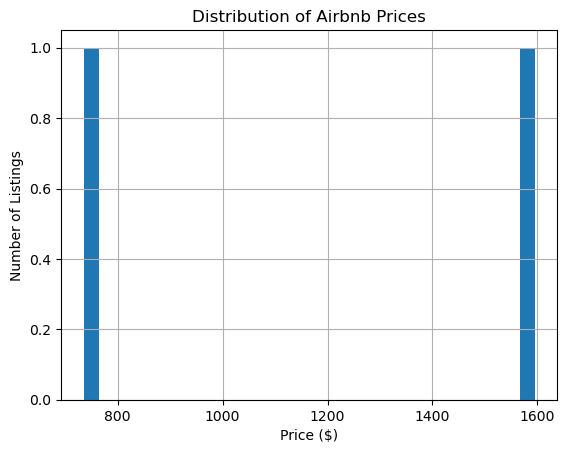

In [61]:
import kagglehub
import os
import pandas as pd
import matplotlib.pyplot as plt

# Download dataset
path = kagglehub.dataset_download("mysarahmadbhat/airbnb-listings-reviews")
print(os.listdir(path))

# Folder where CSV files are stored
folder = os.path.join(path, "Airbnb Data")

# Correct listings file path
listings_path = os.path.join(folder, "Listings.csv")

# Load Kaggle dataset
kaggle_df = pd.read_csv(listings_path, encoding="latin1", low_memory=False)

# Combine with Selenium scraped data
combined = pd.concat([kaggle_df, df_scraped], ignore_index=True)

# Clean scraped price column
df_scraped["price"] = (
    df_scraped["price"]
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
)

df_scraped["price"] = pd.to_numeric(df_scraped["price"], errors="coerce")

# Drop missing prices
df_scraped = df_scraped.dropna(subset=["price"])

# Plot histogram
import matplotlib.pyplot as plt

df_scraped["price"].hist(bins=30)

plt.title("Distribution of Airbnb Prices")
plt.xlabel("Price ($)")
plt.ylabel("Number of Listings")

plt.show()

In [1]:
### improved web scraper

# install libraries needed

!pip install selenium
!pip install webdriver-manager
!pip install beautifulsoup4
!pip install pandas

import time
import pandas as pd

from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys

from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager

from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC

from bs4 import BeautifulSoup


# chrome driver setup
options = webdriver.ChromeOptions()

# Optional: run browser without opening a window
# options.add_argument("headless")

options.add_argument("--start-maximized")

driver = webdriver.Chrome(
    service=Service(ChromeDriverManager().install()),
    options=options
)


#airbnb search page (add a new url for wiki because airbnb does not allow web scraping for student assignments for the most part)
city = "San-Francisco--CA"
url = f"https://www.airbnb.com/s/{city}/homes"

driver.get(url)

time.sleep(5)

print("Page title:", driver.title)
print("Current URL:", driver.current_url)
print("Browser name:", driver.name)


#navigation 
driver.refresh()
print("Page refreshed")
time.sleep(3)

driver.back()
time.sleep(2)

driver.forward()
time.sleep(2)


# get html source
html = driver.page_source

soup = BeautifulSoup(html, "html.parser")

links = soup.find_all("a")

print("Total links found:", len(links))


#scroll to page listings 

listing_urls = set()

for i in range(20):

    driver.execute_script("window.scrollTo(0, document.body.scrollHeight);")

    time.sleep(3)

    cards = driver.find_elements(By.XPATH, '//a[contains(@href,"/rooms/")]')

    for card in cards:

        link = card.get_attribute("href")

        if link and "/rooms/" in link:

            listing_urls.add(link)

    print("Listings collected:", len(listing_urls))


print("Total unique listings:", len(listing_urls))


# scrape each listing
data = []

for listing in list(listing_urls)[:50]:

    driver.get(listing)

    time.sleep(4)

    # Explicit wait for page elements
    try:
        WebDriverWait(driver,10).until(
            EC.presence_of_element_located((By.TAG_NAME,"h1"))
        )
    except:
        pass

    try:
        title = driver.find_element(By.TAG_NAME,"h1").text
    except:
        title = None

    try:
        price = driver.find_element(By.XPATH,'//span[contains(text(),"$")]').text
    except:
        price = None

    try:
        rating = driver.find_element(By.XPATH,'//span[contains(text(),"★")]').text
    except:
        rating = None

    try:
        description = driver.find_element(By.TAG_NAME,"body").text[:200]
    except:
        description = None

    data.append({
        "title":title,
        "price":price,
        "rating":rating,
        "url":listing,
        "description":description
    })

    print("Scraped:", title)


# create dataframe 
df = pd.DataFrame(data)

print(df.head())


#clean data (perhaps repetitive)
df["price"] = (
    df["price"]
    .astype(str)
    .str.replace("$","",regex=False)
    .str.replace(",","",regex=False)
)

df["price"] = pd.to_numeric(df["price"], errors="coerce")

df["rating"] = (
    df["rating"]
    .astype(str)
    .str.replace("★","",regex=False)
)

df["rating"] = pd.to_numeric(df["rating"], errors="coerce")

df = df.dropna(subset=["price"])


#save data 
df.to_csv("airbnb_scraped_listings.csv", index=False)

print("\nTotal listings scraped:", len(df))
print(df.head())

#close browser
driver.quit()

Page title: Airbnb | San Francisco - Vacation Rentals & Places to Stay - California
Current URL: https://www.airbnb.com/s/San-Francisco--CA/homes
Browser name: chrome
Page refreshed
Total links found: 176
Listings collected: 18
Listings collected: 18
Listings collected: 18
Listings collected: 18


InvalidSessionIdException: Message: invalid session id: session deleted as the browser has closed the connection
from disconnected: not connected to DevTools
  (Session info: chrome=145.0.7632.162); For documentation on this error, please visit: https://www.selenium.dev/documentation/webdriver/troubleshooting/errors#invalidsessionidexception
Stacktrace:
Symbols not available. Dumping unresolved backtrace:
	0x5f7dd3
	0x5f7e14
	0x401db0
	0x3f0d4e
	0x40f895
	0x4752ec
	0x48b0d9
	0x46e7d6
	0x440049
	0x440e04
	0x856924
	0x851bf7
	0x86f5a0
	0x610f58
	0x61891d
	0x600648
	0x600812
	0x5ea21a
	0x776583e8
	0x775ae81c
	0x77b7fcfc
	0x77b7fc58
	0x77c596fc


In [19]:
!pip install kaggle
-
# Install required packages

!pip install kaggle
!pip install kagglehub
!pip install pandas


# Import libraries

import kagglehub
import os
import pandas as pd


# Download the Kaggle dataset

import kagglehub

# Download latest version
path = kagglehub.dataset_download("mysarahmadbhat/airbnb-listings-reviews")

#Path/foldername:
folder = os.path.join(path, 'Airbnb Data')

#Each file: 
listings_path =os.path.join(folder, "Listings.csv")
listing_dict_path = os.path.join(folder, "Reviews_data_dictionary.csv")
review_path = os.path.join(folder, "Reviews.csv")
review_dict_path = os.path.join(folder, "Listings_data_dictionary.csv")
listing_df = pd.read_csv(listings_path, encoding="latin1", low_memory = False) #'utf-8' codec error. Named old_ because data cleaning is necessary.
listing_dict = pd.read_csv(listing_dict_path, low_memory = False)
review_df = pd.read_csv(review_path, low_memory = False)
review_dict= pd.read_csv(review_dict_path, low_memory = False)


# Now kaggle_df is loaded and ready for analysis or comparison

# url = 'http://insideairbnb.com/get-the-data.html'

#install seleium 
!pip install selenium
!pip install webdriver-manager

import time
import pandas as pd

from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager

# setup driver
driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()))

url = "http://insideairbnb.com/get-the-data.html"
driver.get(url)

time.sleep(5)

# find all CSV download links
links = driver.find_elements(By.XPATH, '//a[contains(@href,"listings.csv")]')

data_links = []

for link in links:
    href = link.get_attribute("href")
    data_links.append(href)

print("Found datasets:", len(data_links))

for l in data_links[:5]:
    print(l)

driver.quit()

#download scraped datasets
inside_url = data_links[0]

inside_df = pd.read_csv(inside_url, compression="gzip")

print(inside_df.head())

#clean price columns
def clean_price(series):
    return (
        series.astype(str)
        .str.replace("$","",regex=False)
        .str.replace(",","",regex=False)
        .astype(float)
    )

kaggle_df["price"] = clean_price(kaggle_df["price"])
inside_df["price"] = clean_price(inside_df["price"])

#compare average prices
print("Kaggle dataset average price:")
print(kaggle_df["price"].mean())

print("\nInsideAirbnb dataset average price:")
print(inside_df["price"].mean())

#^ price comparisions

#compare room type prices
sns.boxplot(data=kaggle_df, x="room_type", y="price")

plt.title("Price by Room Type (Kaggle)")
plt.show()

sns.boxplot(data=inside_df, x="room_type", y="price")

plt.title("Price by Room Type (InsideAirbnb)")
plt.show()

#compare price vs rating
sns.scatterplot(
    data=kaggle_df,
    x="review_scores_rating",
    y="price",
    alpha=0.3
)

plt.title("Price vs Rating (Kaggle)")
plt.show()

Found datasets: 242
https://data.insideairbnb.com/united-states/ny/albany/2025-11-07/data/listings.csv.gz
https://data.insideairbnb.com/united-states/ny/albany/2025-11-07/visualisations/listings.csv
https://data.insideairbnb.com/the-netherlands/north-holland/amsterdam/2025-09-11/data/listings.csv.gz
https://data.insideairbnb.com/the-netherlands/north-holland/amsterdam/2025-09-11/visualisations/listings.csv
https://data.insideairbnb.com/belgium/vlg/antwerp/2025-09-28/data/listings.csv.gz
        id                           listing_url       scrape_id last_scraped  \
0  2992450  https://www.airbnb.com/rooms/2992450  20251107023918   2025-11-07   
1  3820211  https://www.airbnb.com/rooms/3820211  20251107023918   2025-11-07   
2  5651579  https://www.airbnb.com/rooms/5651579  20251107023918   2025-11-07   
3  6623339  https://www.airbnb.com/rooms/6623339  20251107023918   2025-11-07   
4  9005989  https://www.airbnb.com/rooms/9005989  20251107023918   2025-11-07   

        source       

NameError: name 'kaggle_df' is not defined

C:\Users\kenzi\AppData\Local\Temp\ipykernel_10708\479980177.py:35: DtypeWarning: Columns (5,13) have mixed types. Specify dtype option on import or set low_memory=False.


Kaggle Listings data loaded:
   listing_id                                              name   host_id  \
0      281420    Beautiful Flat in le Village Montmartre, Paris   1466919   
1     3705183                   39 mÃÂ² Paris (Sacre CÃâur)  10328771   
2     4082273               Lovely apartment with Terrace, 60m2  19252768   
3     4797344               Cosy studio (close to Eiffel tower)  10668311   
4     4823489  Close to Eiffel Tower - Beautiful flat : 2 rooms  24837558   

   host_since                 host_location host_response_time  \
0  2011-12-03  Paris, Ile-de-France, France                NaN   
1  2013-11-29  Paris, Ile-de-France, France                NaN   
2  2014-07-31  Paris, Ile-de-France, France                NaN   
3  2013-12-17  Paris, Ile-de-France, France                NaN   
4  2014-12-14  Paris, Ile-de-France, France                NaN   

   host_response_rate  host_acceptance_rate host_is_superhost  \
0                 NaN                   NaN   

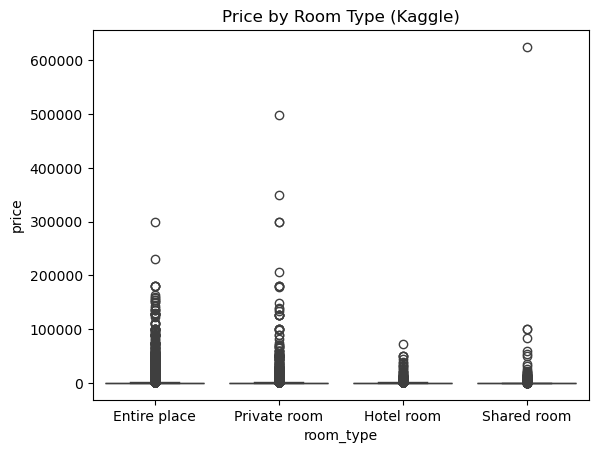

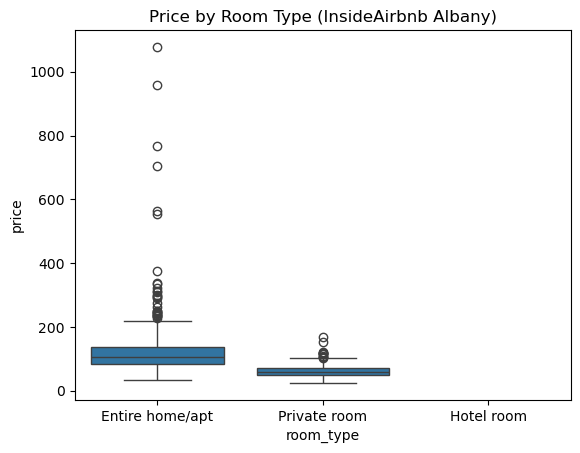

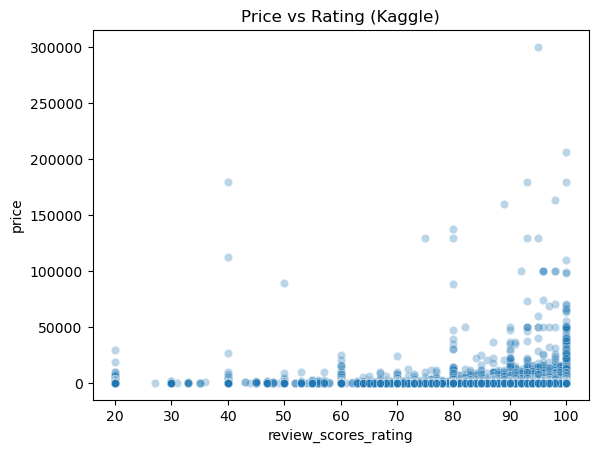

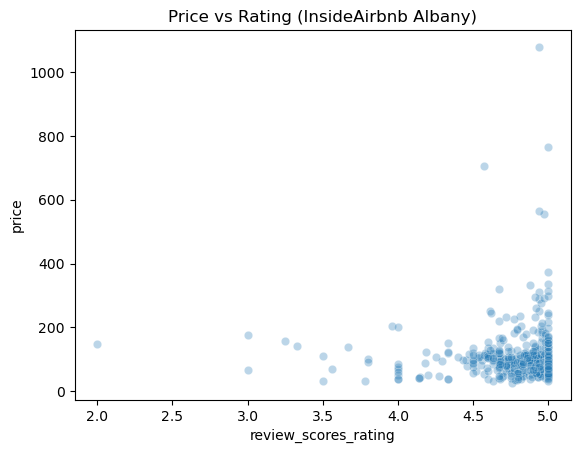

In [30]:
# import needed libraries
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import time
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager


# Define Kaggle folder paths
# 'path' is the root folder returned by kagglehub.dataset_download
# and your CSV files are inside a subfolder "Airbnb Data"
folder = os.path.join(path, 'Airbnb Data')

# Make sure the folder exists
if not os.path.exists(folder):
    raise FileNotFoundError(f"Folder not found: {folder}")

# Define each CSV file path
listings_path = os.path.join(folder, "Listings.csv")
listing_dict_path = os.path.join(folder, "Reviews_data_dictionary.csv")
review_path = os.path.join(folder, "Reviews.csv")
review_dict_path = os.path.join(folder, "Listings_data_dictionary.csv")


# Load main Listings CSV

if not os.path.exists(listings_path):
    raise FileNotFoundError(f"Listings file not found: {listings_path}")

# reading with ISO-8859-1 encoding
kaggle_df = pd.read_csv(listings_path, encoding="ISO-8859-1")

print("Kaggle Listings data loaded:")
print(kaggle_df.head())


# Scrape InsideAirbnb for a specific city

city = "albany"
country = "united-states"

driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()))
url = "http://insideairbnb.com/get-the-data.html"
driver.get(url)
time.sleep(5)

links = driver.find_elements(By.XPATH, '//a[contains(@href,"listings.csv")]')
city_links = [link.get_attribute("href") for link in links if city.lower() in link.get_attribute("href") and country.lower() in link.get_attribute("href")]

if not city_links:
    driver.quit()
    raise ValueError(f"No InsideAirbnb datasets found for {city}, {country}")

inside_url = city_links[0]
print("Using InsideAirbnb dataset:", inside_url)

driver.quit()
inside_df = pd.read_csv(inside_url, compression="gzip")
print("InsideAirbnb data loaded:")
print(inside_df.head())


# SClean price columns

def clean_price(series):
    return series.astype(str).str.replace("$","",regex=False).str.replace(",","",regex=False).astype(float)

kaggle_df["price"] = clean_price(kaggle_df["price"])
inside_df["price"] = clean_price(inside_df["price"])


# Compare average prices

print("Kaggle average price:", kaggle_df["price"].mean())
print("InsideAirbnb average price:", inside_df["price"].mean())
len(inside_url)

# Compare room type prices

sns.boxplot(data=kaggle_df, x="room_type", y="price")
plt.title("Price by Room Type (Kaggle)")
plt.show()

sns.boxplot(data=inside_df, x="room_type", y="price")
plt.title(f"Price by Room Type (InsideAirbnb {city.title()})")
plt.show()


#Compare price vs rating

sns.scatterplot(data=kaggle_df, x="review_scores_rating", y="price", alpha=0.3)
plt.title("Price vs Rating (Kaggle)")
plt.show()

sns.scatterplot(data=inside_df, x="review_scores_rating", y="price", alpha=0.3)
plt.title(f"Price vs Rating (InsideAirbnb {city.title()})")
plt.show()

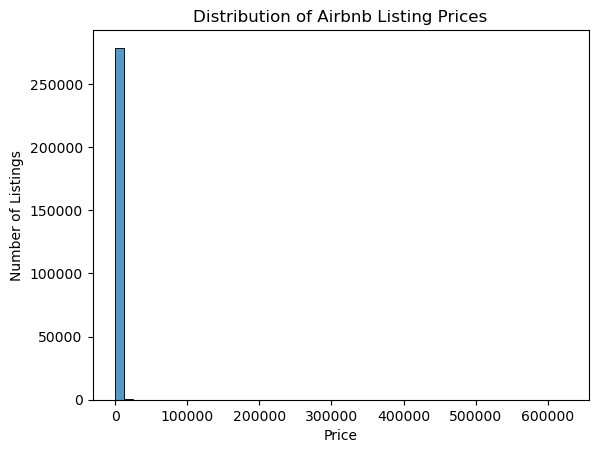

In [32]:
sns.histplot(kaggle_df["price"], bins=50)
plt.title("Distribution of Airbnb Listing Prices")
plt.xlabel("Price")
plt.ylabel("Number of Listings")
plt.show()

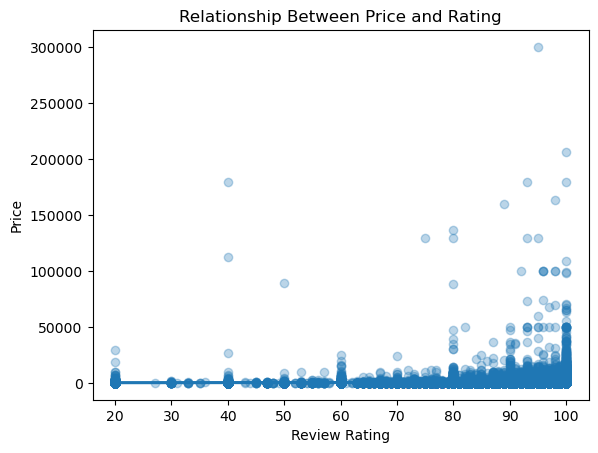

In [34]:
sns.regplot(data=kaggle_df,
            x="review_scores_rating",
            y="price",
            scatter_kws={"alpha":0.3})

plt.title("Relationship Between Price and Rating")
plt.xlabel("Review Rating")
plt.ylabel("Price")
plt.show()

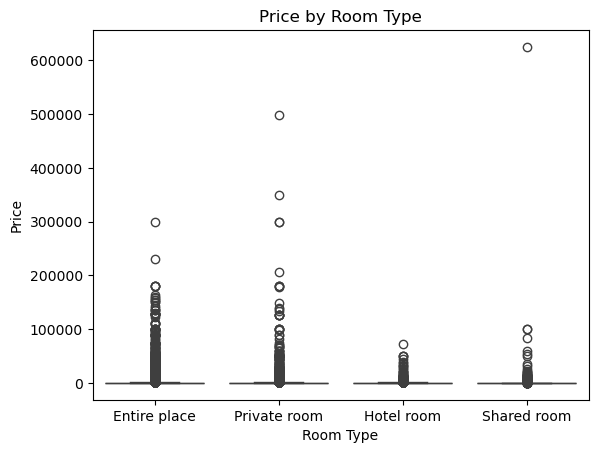

In [35]:
sns.boxplot(data=kaggle_df, x="room_type", y="price")
plt.title("Price by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Price")
plt.show()

In [36]:
sns.scatterplot(data=kaggle_df,
                x="number_of_reviews",
                y="price",
                alpha=0.3)

plt.title("Price vs Number of Reviews")
plt.xlabel("Number of Reviews")
plt.ylabel("Price")
plt.show()

ValueError: Could not interpret value `number_of_reviews` for `x`. An entry with this name does not appear in `data`.

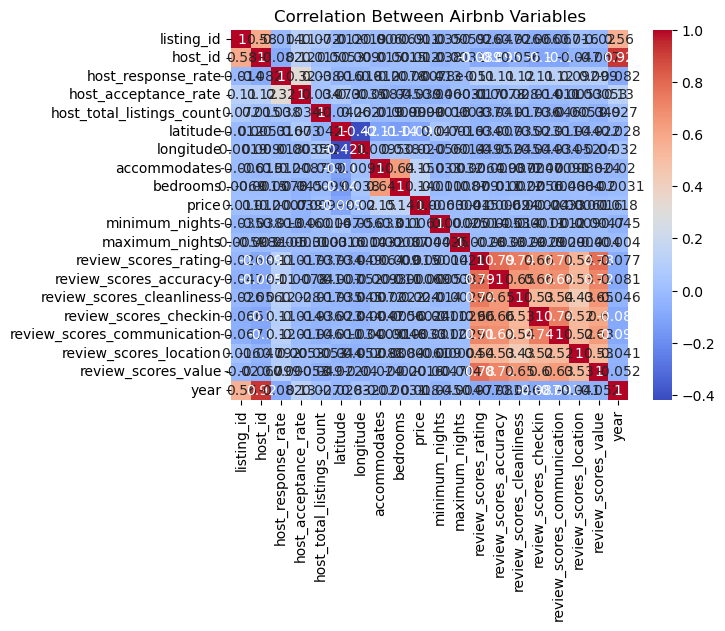

In [39]:
numeric_df = kaggle_df.select_dtypes(include="number")

corr = numeric_df.corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Between Airbnb Variables")
plt.show()

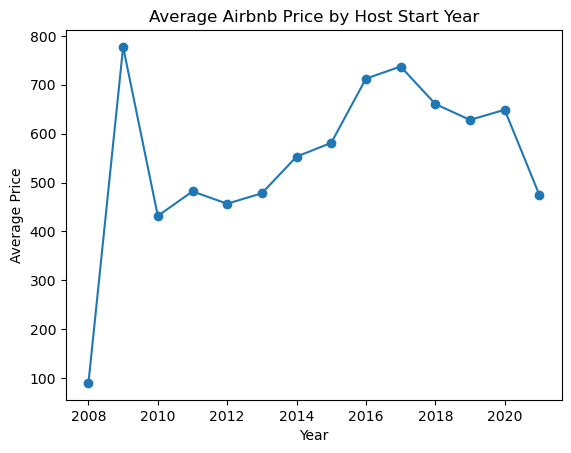

In [38]:
kaggle_df["host_since"] = pd.to_datetime(kaggle_df["host_since"], errors="coerce")
kaggle_df["year"] = kaggle_df["host_since"].dt.year

price_trend = kaggle_df.groupby("year")["price"].mean()

plt.plot(price_trend.index, price_trend.values, marker="o")
plt.title("Average Airbnb Price by Host Start Year")
plt.xlabel("Year")
plt.ylabel("Average Price")
plt.show()

In [ ]:
sns.scatterplot(data=kaggle_df,
                x="availability_365",
                y="price",
                alpha=0.3)

plt.title("Price vs Availability")
plt.xlabel("Availability (Days per Year)")
plt.ylabel("Price")
plt.show()